# Atividade Prática Extra 

O estudante deverá utilizar a base de dados pública do Titanic, em formato CSV, com o
objetivo de realizar uma Análise Exploratória de Dados (AED). A atividade consiste em
importar, organizar e analisar o conjunto de dados, buscando compreender o
comportamento geral das informações e identificar padrões, relações entre variáveis e
possíveis fatores associados à sobrevivência dos passageiros. A partir desse processo,
espera-se a obtenção de insights relevantes, como estatísticas descritivas, distribuições,
comparações entre grupos e análises exploratórias das variáveis disponíveis.

A base de dados pública do Titanic, em formato CSV, está disponível neste endereço
eletrônico: https://drive.google.com/file/d/11HptTxJbUMRG16xpC39fcliba_-Z_J9d/

## Importações

In [1]:
# Importar bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [2]:
# Importar dataset

df = pd.read_csv('titanic_dataset.csv')

print(f'Dataset importado com sucesso!\n')
print(f'As 10 primeiras linhas do Dataset são:\n{df.head(10)}\n')



Dataset importado com sucesso!

As 10 primeiras linhas do Dataset são:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN    

## Primeiras informações:

In [3]:
# Resumo técnico do dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Resumo estatístico das colunas numéricas:

print(f'Estatística descritiva do dataset:\n{df.describe()}')

Estatística descritiva do dataset:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [5]:
# Verificação do total de valores nulos

valores_nulos = df.isnull().sum()
print(f'Valores nulos de cada coluna:\n{valores_nulos}\n')

# Verificação da porcentagem de nulos

porcentagem_nulos = ((df.isnull().sum() / len(df)) * 100).round(0)
print(f'Porcentagem de valores nulos:\n{porcentagem_nulos}')

Valores nulos de cada coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Porcentagem de valores nulos:
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            20.0
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.0
Embarked        0.0
dtype: float64


## Limpeza dos dados

In [6]:
# Removendo a coluna 'Cabin', já que ela possui mais que 70% de valores nulos e não ajudará na análise

df.drop(columns=['Cabin'], inplace=True)


In [7]:
# Verificação

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [8]:
# Removendo 2 linhas onde há nulos na coluna 'Embarked'

df.dropna(subset=['Embarked'], inplace=True)

In [9]:
#Verificação

df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


In [10]:
# Preenchendo coluna 'Age' com a mediana

age_median = df['Age'].median()
print(f'A mediana da coluna idade é {age_median}!\n')

df['Age'] = df['Age'].fillna(age_median)
print('Preenchimento concluído!')


A mediana da coluna idade é 28.0!

Preenchimento concluído!


In [11]:
# Verificação

df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


In [12]:
# Agora que todas as colunas estão preenchidas, verifico a exixtência de valores duplicados

print(f"Total de duplicados: {df.duplicated().sum()}")



Total de duplicados: 0


In [13]:
# Para facilitar a próxima etapa, vou trocar o nome das colunas para o português

df = df.rename(columns={
    'PassengerId': 'id_passageiro',
    'Survived': 'sobreviveu',
    'Pclass': 'classe',
    'Name': 'nome',
    'Sex': 'genero',
    'Age': 'idade',
    'SibSp': 'irmaos_conjugue',
    'Parch': 'pais_filhos',
    'Ticket': 'bilhete',
    'Fare': 'tarifa',
    'Embarked': 'porto_embarque'

})

print(f'Nomes das colunas traduzidos para o Português!')

Nomes das colunas traduzidos para o Português!


In [14]:
# Verificação

df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_passageiro    889 non-null    int64  
 1   sobreviveu       889 non-null    int64  
 2   classe           889 non-null    int64  
 3   nome             889 non-null    str    
 4   genero           889 non-null    str    
 5   idade            889 non-null    float64
 6   irmaos_conjugue  889 non-null    int64  
 7   pais_filhos      889 non-null    int64  
 8   bilhete          889 non-null    str    
 9   tarifa           889 non-null    float64
 10  porto_embarque   889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


## Análise

In [15]:
# Primeiro vamos ver a distribuição de passageiro. Se sobreviveu, idade, gênero, classe que ocupava e quanto pagou

# Sobreviveu
print(f'{(df['sobreviveu'].value_counts(normalize=True) * 100).round(0)}\n')

# Idade
print(f'Estatísticas de Idade:\n{df['idade'].describe()}\n')

# Genero
print(f'{df['genero'].value_counts()}\n')

# Classe
print(f'{df['classe'].value_counts()}\n')

# Tarifa
print(f'Preços:\n{df['tarifa'].describe()}\n')


sobreviveu
0    62.0
1    38.0
Name: proportion, dtype: float64

Estatísticas de Idade:
count    889.000000
mean      29.315152
std       12.984932
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: idade, dtype: float64

genero
male      577
female    312
Name: count, dtype: int64

classe
3    491
1    214
2    184
Name: count, dtype: int64

Preços:
count    889.000000
mean      32.096681
std       49.697504
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: tarifa, dtype: float64



In [16]:
# Agora já posso descobrir o perfil de quem sobreviveu cruzando as variáveis
print(f'Sobreviventes (%) por:\n')
print(f'{(df.groupby('genero')['sobreviveu'].mean() * 100).round(0)}\n')
print(f'{(df.groupby('classe')['sobreviveu'].mean() * 100).round(0)}\n')


Sobreviventes (%) por:

genero
female    74.0
male      19.0
Name: sobreviveu, dtype: float64

classe
1    63.0
2    47.0
3    24.0
Name: sobreviveu, dtype: float64



In [17]:
# Saber a média de idade de quem sobreviveu

print((df.groupby('sobreviveu')['idade'].mean()).round(0))

sobreviveu
0    30.0
1    28.0
Name: idade, dtype: float64


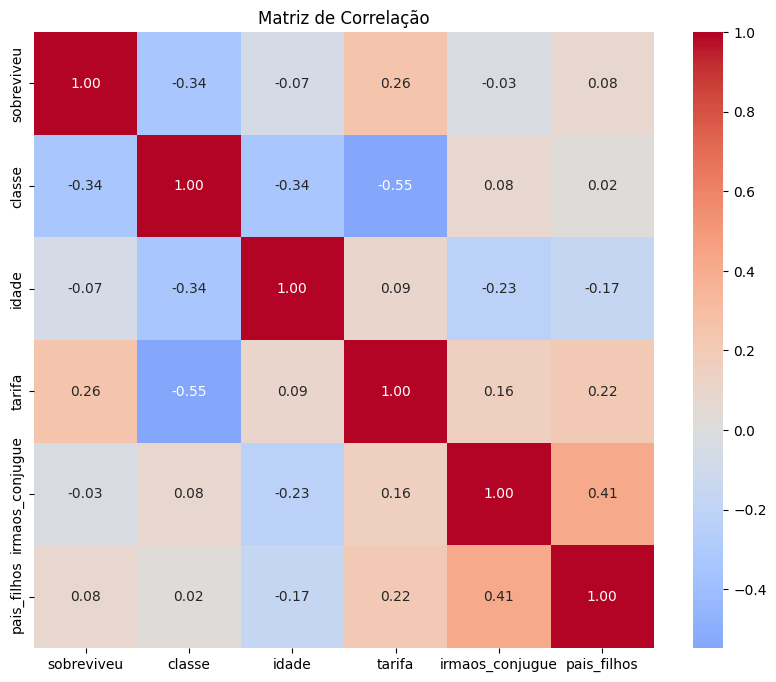

In [18]:
# Entendendo a correlação das colunas numéricas

corr = df[['sobreviveu', 'classe', 'idade', 'tarifa', 'irmaos_conjugue', 'pais_filhos']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)


plt.title('Matriz de Correlação')
plt.savefig('archive/matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

Pontos chave:

- Fraca influência da idade na sobrevivência;
- Forte influência da classe e do valor pago pela passagem para sobreviver;
- Quanto maior a classe, muito maior o valor pago;
- Forte correlação entre as colunas de parentescos, mostrando que haviam muitas famílias a bordo;

## Visualização

Com base nas informações dos dados e na análise da matriz de calor, podemos tirar alguns insights que os demais gráficos nos revelarão melhor:

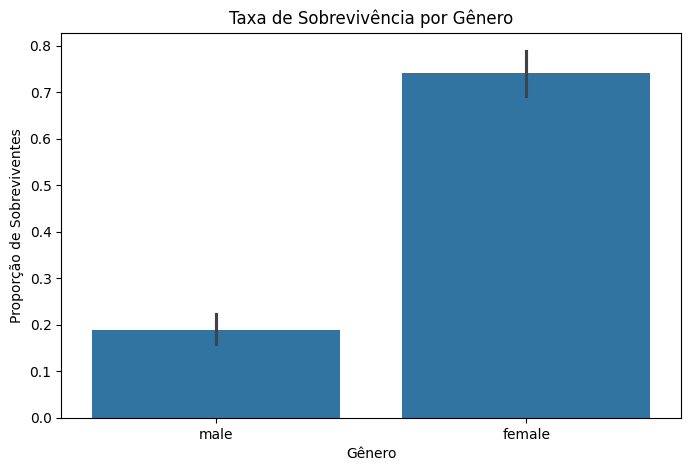

In [19]:
# Sobrevivência vs. Gênero

plt.figure(figsize=(8, 5))

sns.barplot(data=df, x='genero', y='sobreviveu')


plt.title('Taxa de Sobrevivência por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Proporção de Sobreviventes')

plt.savefig('archive/sob_vs_gen.png', dpi=300, bbox_inches='tight')
plt.show()

Podemos notar que a política de "mulheres e crianças primeiro" funcionou.

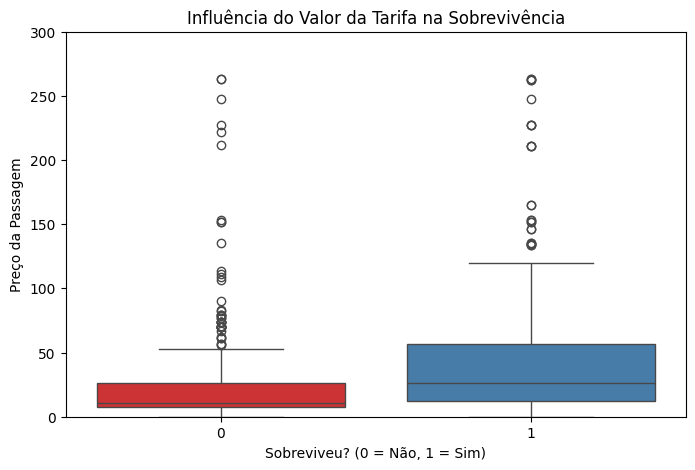

In [20]:
# Sobrevivência vs. Valor da Tarifa (-0.26)

plt.figure(figsize=(8, 5))
sns.boxplot(x='sobreviveu', y='tarifa', data=df, palette='Set1', hue='sobreviveu', legend=False)

plt.title('Influência do Valor da Tarifa na Sobrevivência')

plt.xlabel('Sobreviveu? (0 = Não, 1 = Sim)')
plt.ylabel('Preço da Passagem')
plt.ylim(0, 300) # Limitando para ignorar o outlier de 500 e focar na caixa

plt.savefig('archive/sob_vs_tarifa.png', dpi=300, bbox_inches='tight')
plt.show()

Quanto maior o valor pago na passagem, maiores as chances de sobreviver.

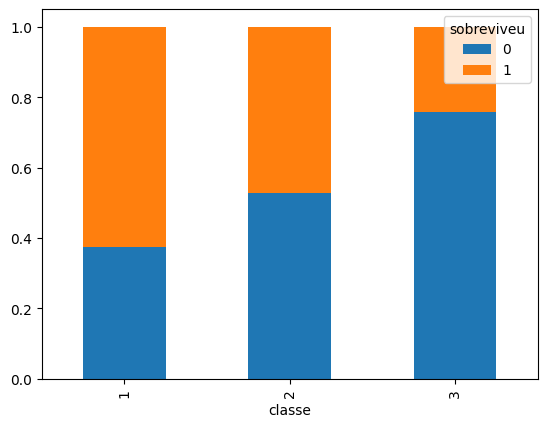

In [21]:
# Sobrevivência vs. Classe (-0.34)

pd.crosstab(df['classe'], df['sobreviveu'], normalize='index').plot(kind='bar', stacked=True)

plt.xticks() 

plt.savefig('archive/sob_vs_classe.png', dpi=300, bbox_inches='tight')
plt.show()

Quanto maior a classe, mais chances de sobreviver.

/tmp/ipykernel_3962/875371381.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classe', y='tarifa', data=df, palette='Set2')


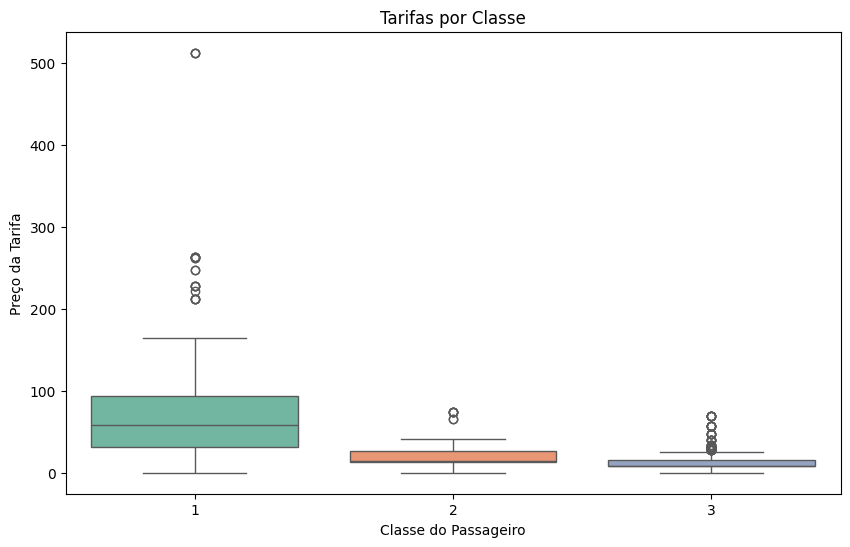

In [22]:
# Valor vs Classe

plt.figure(figsize=(10, 6))
sns.boxplot(x='classe', y='tarifa', data=df, palette='Set2')

plt.title('Tarifas por Classe')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Preço da Tarifa')

plt.savefig('archive/valor_vs_classe.png', dpi=300, bbox_inches='tight')
plt.show()

- Concluímos que principalmente na primeira classe há presença de **Outliers extremos**, comprovando que alguns pagaram valores muito maiores pela passagem 
- Também na primeira classe a variação de preço era alta;
- Nas demais classes não há muita variação no valor, apenas na classe 3 temos a presença de alguns outliers;